# Extend LUH: Data Exploration & Validation

Explore the input data and verify the extension strategy for **REMIND-MAgPIE 3.5-4.11, SSP1 - Very Low Emissions**.

1. AFOLU rampdown trajectory (CSV) and gridded rate-of-change
2. BECCS scaling curve and biofuel crop fractions
3. Prototype extension and sanity checks

In [1]:
import sys, os
sys.path.insert(0, os.path.join(os.path.dirname(os.path.abspath('.')), 'extend-luh'))
# Also handle running from notebooks/ dir
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
from src import config as cfg
from src.data import (
    load_csv, filter_scenario, get_variable,
    beccs_scaling_factors, afolu_ramp,
    load_states, load_biof, state_2100, rates_2100,
)

%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 4)

## 1. AFOLU + BECCS trajectories from CSV

The IAM CSV provides global and regional emissions out to 2500. Two variables drive the gridded extension:

- **AFOLU CO₂**: Emissions decline linearly to zero after 2100, setting the timeline over which we decay per-cell land-use change rates. We use this shape — not the absolute magnitude — because matching the emissions integral would require carbon-density fields from the ESM that we don't have.
- **BECCS**: Carbon Dioxide Removal via bioenergy with CCS rises after 2100, peaks, then falls back toward zero. We take the ratio relative to 2100 as a scaling factor for biofuel crop fractions. All REMIND regions share identical scaling factors, so a single global curve is sufficient.

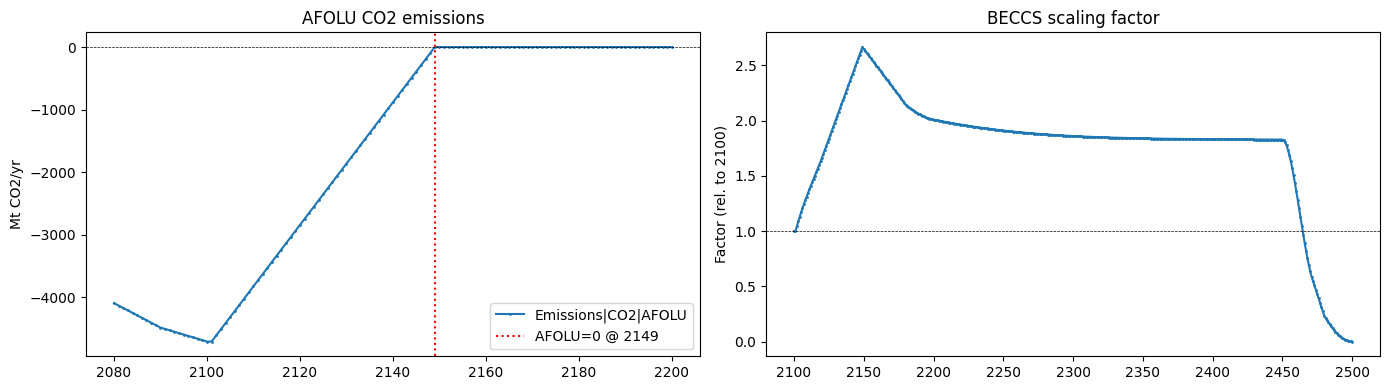

In [2]:
df = load_csv()
sc = filter_scenario(df)

afolu = get_variable(sc, 'Emissions|CO2|AFOLU')
beccs = beccs_scaling_factors(sc)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

ax = axes[0]
afolu.loc[2080:2200].plot(ax=ax, marker='.', ms=2)
ax.axhline(0, color='k', ls='--', lw=0.5)
ax.axvline(cfg.YR_AFOLU_ZERO, color='r', ls=':', label=f'AFOLU=0 @ {cfg.YR_AFOLU_ZERO}')
ax.set_ylabel('Mt CO2/yr'); ax.set_title('AFOLU CO2 emissions'); ax.legend()

ax = axes[1]
beccs.loc[2100:2500].plot(ax=ax, marker='.', ms=2)
ax.axhline(1, color='k', ls='--', lw=0.5)
ax.set_ylabel('Factor (rel. to 2100)'); ax.set_title('BECCS scaling factor')

plt.tight_layout(); plt.show()

## 2. Gridded state rates at 2100

We compute per-cell rates of change as the difference between the last two input timesteps. These rates are constant over the final decade of the input (verified), so the last-year difference is a robust and representative baseline.

The table below shows global sums for each state variable at 2100, the net rate, and the estimated cumulative change under a linear ramp-to-zero (integral = rate × n_years / 2). This gives a first-order sense of how much land shifts before the ramp ends.

**Table columns:**
- **Variable** — one of the 13 state fractions (sum to 1.0 per land cell):
  `primf` / `secdf` (primary / secondary forest),
  `primn` / `secdn` (primary / secondary non-forest),
  `c3ann` / `c3nfx` / `c3per` / `c4ann` / `c4per` (crop types),
  `pastr` / `range` (managed pasture / rangeland),
  `urban`, `pltns` (plantations)
- **2100 sum** — global sum of the fraction field (larger = more area)
- **Rate/yr** — global net rate of change at 2100 (positive = expanding, negative = shrinking)
- **Δ by end** — estimated total shift by the time the ramp reaches zero
- **End est** — projected global sum after the ramp (2100 sum + Δ)

In [3]:
ds_states = load_states()
vals = state_2100(ds_states)
rates = rates_2100(ds_states)

# Global budget table
print(f'{"Variable":10s} {"2100 sum":>12s} {"Rate/yr":>12s} {"Δ by 2149":>12s} {"2149 est":>12s}')
print('-' * 60)
for v in cfg.STATE_VARS:
    s = np.nansum(vals[v])
    r = np.nansum(rates[v])
    delta = r * 49 / 2  # integral of linear ramp
    print(f'{v:10s} {s:12.1f} {r:12.2f} {delta:12.1f} {s+delta:12.1f}')

Variable       2100 sum      Rate/yr    Δ by 2149     2149 est
------------------------------------------------------------
primf           33423.7       -17.27       -423.0      33000.7
secdf           45704.0        84.59       2072.5      47776.6
primn           46183.8        -3.35        -82.1      46101.8
secdn           35869.6        21.76        533.1      36402.8
c3ann            8995.3       -34.86       -854.0       8141.2
c3nfx            3938.4       -25.21       -617.7       3320.7
c3per            2923.5        -6.44       -157.7       2765.8
c4ann            3213.8       -10.00       -245.0       2968.8
c4per            2054.8         1.94         47.5       2102.3
pastr            8355.0        -3.80        -93.2       8261.8
range           34349.7        -1.72        -42.0      34307.6
urban            1641.1        -5.50       -134.9       1506.2
pltns            2640.2         1.33         32.5       2672.7


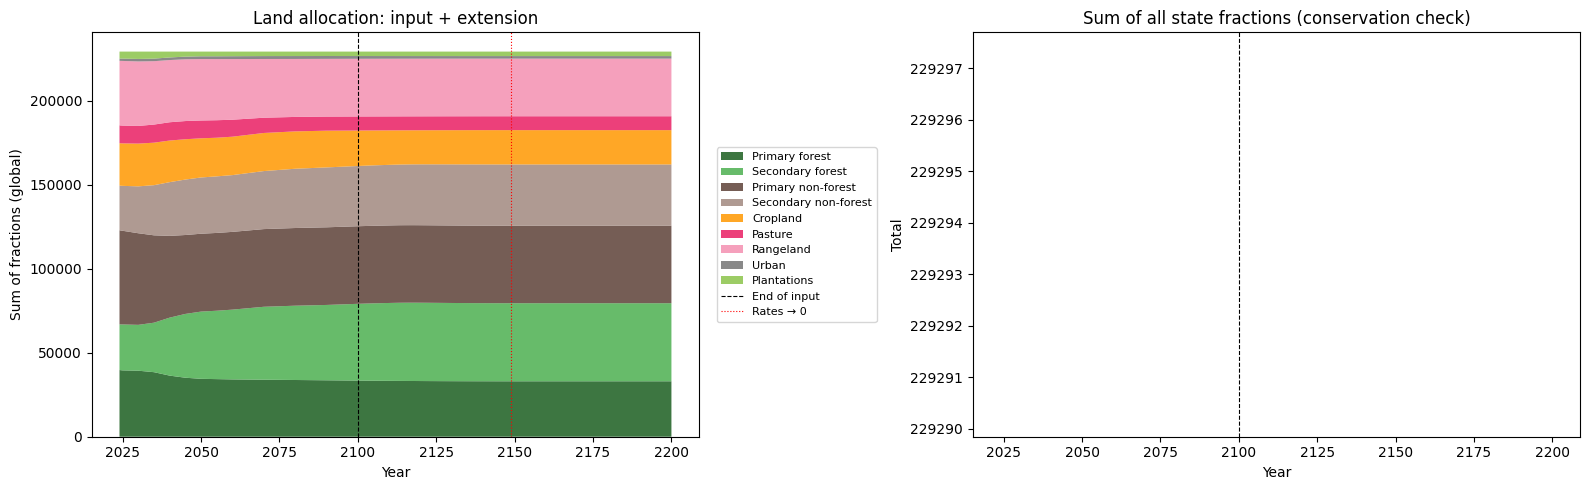

In [9]:
# Stacked area plot: input period + extension
import importlib, src.extend
importlib.reload(src.extend)
from src.extend import extend_states as _extend_states

ext_yrs_area = np.arange(2101, 2201)
ext = _extend_states(vals, rates, ext_yrs_area)

years_in = np.arange(2024, 2101)
all_years = np.concatenate([years_in, ext_yrs_area])

groups = {
    'Primary forest':       ['primf'],
    'Secondary forest':     ['secdf'],
    'Primary non-forest':   ['primn'],
    'Secondary non-forest': ['secdn'],
    'Cropland':             ['c3ann', 'c3nfx', 'c3per', 'c4ann', 'c4per'],
    'Pasture':              ['pastr'],
    'Rangeland':            ['range'],
    'Urban':                ['urban'],
    'Plantations':          ['pltns'],
}

colors = ['#1b5e20', '#4caf50', '#5d4037', '#a1887f',
          '#ff9800', '#e91e63', '#f48fb1', '#757575', '#8bc34a']

# Build timeseries: input from ds_states, extension from ext dict
group_sums = {}
for label, varlist in groups.items():
    hist_ts = np.array([
        sum(np.nansum(ds_states[v].isel(time=t).values) for v in varlist)
        for t in range(len(years_in))
    ])
    ext_ts = np.array([
        sum(np.nansum(ext[v][t]) for v in varlist)
        for t in range(len(ext_yrs_area))
    ])
    group_sums[label] = np.concatenate([hist_ts, ext_ts])

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Left: stacked area spanning input + extension
ax = axes[0]
labels = list(groups.keys())
data = np.array([group_sums[l] for l in labels])
ax.stackplot(all_years, data, labels=labels, colors=colors, alpha=0.85)
ax.axvline(cfg.YR_END_INPUT, color='k', ls='--', lw=0.8, label='End of input')
ax.axvline(cfg.YR_AFOLU_ZERO, color='r', ls=':', lw=0.8, label='Rates → 0')
ax.set_xlabel('Year'); ax.set_ylabel('Sum of fractions (global)')
ax.set_title('Land allocation: input + extension')
ax.legend(loc='center left', bbox_to_anchor=(1.02, 0.5), fontsize=8)

# Right: total sum — conservation check across the join
ax = axes[1]
total = data.sum(axis=0)
ax.plot(all_years, total/total[0], 'k-', lw=1.5)
ax.axvline(cfg.YR_END_INPUT, color='k', ls='--', lw=0.8)
ax.set_xlabel('Year'); ax.set_ylabel('Total')
ax.set_title('Sum of all state fractions (conservation check)')
ax.ticklabel_format(useOffset=False)
ymin, ymax = total.min(), total.max()
margin = max(ymax - ymin, 0.01) * 2
ax.set_ylim(ymin - margin, ymax + margin)

plt.tight_layout(); plt.show()

## 3. Rate ramp vs AFOLU trajectory

We overlay the linear rate multiplier (1 → 0) on the normalised AFOLU emissions curve. The multiplier is applied to every cell's rate of change each year, so the entire gridded field smoothly converges to a steady state.

We deliberately match the *shape and timing* of the AFOLU curve rather than the emissions integral. The integral depends on ESM-derived carbon densities that vary spatially and aren't available to us — so we treat the CSV as a temporal guide, not an absolute constraint.

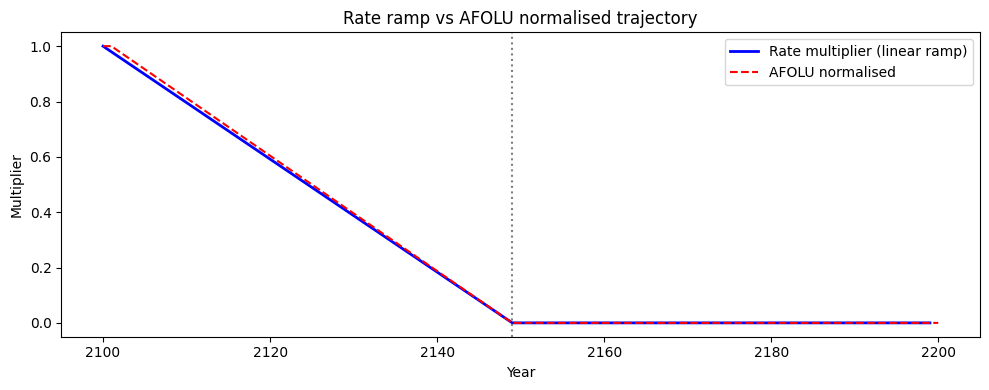

In [5]:
yrs = np.arange(2100, 2200)
ramp = afolu_ramp(yrs)

# Normalise AFOLU to same scale for overlay
afolu_norm = afolu.loc[2100:2200] / afolu.loc[2100]

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(yrs, ramp, 'b-', lw=2, label='Rate multiplier (linear ramp)')
ax.plot(afolu_norm.index, afolu_norm.values, 'r--', lw=1.5, label='AFOLU normalised')
ax.axvline(cfg.YR_AFOLU_ZERO, color='gray', ls=':')
ax.set_xlabel('Year'); ax.set_ylabel('Multiplier')
ax.set_title('Rate ramp vs AFOLU normalised trajectory')
ax.legend(); plt.tight_layout(); plt.show()

## 4. Prototype extension — global sums

Year-by-year forward stepping applies the ramped rates to each cell. Where a declining variable would go negative, it is clamped to zero and the excess area is redirected to secondary forest (secdf), preserving the per-cell sum-to-one constraint. After the ramp reaches zero, land use is frozen for all remaining years.

The four panels show: forest (primf, secdf), cropland types, the total state-fraction sum (conservation check), and secondary forest alone — which absorbs the excess from clamped cells and should show a slight upward bump during the ramp.

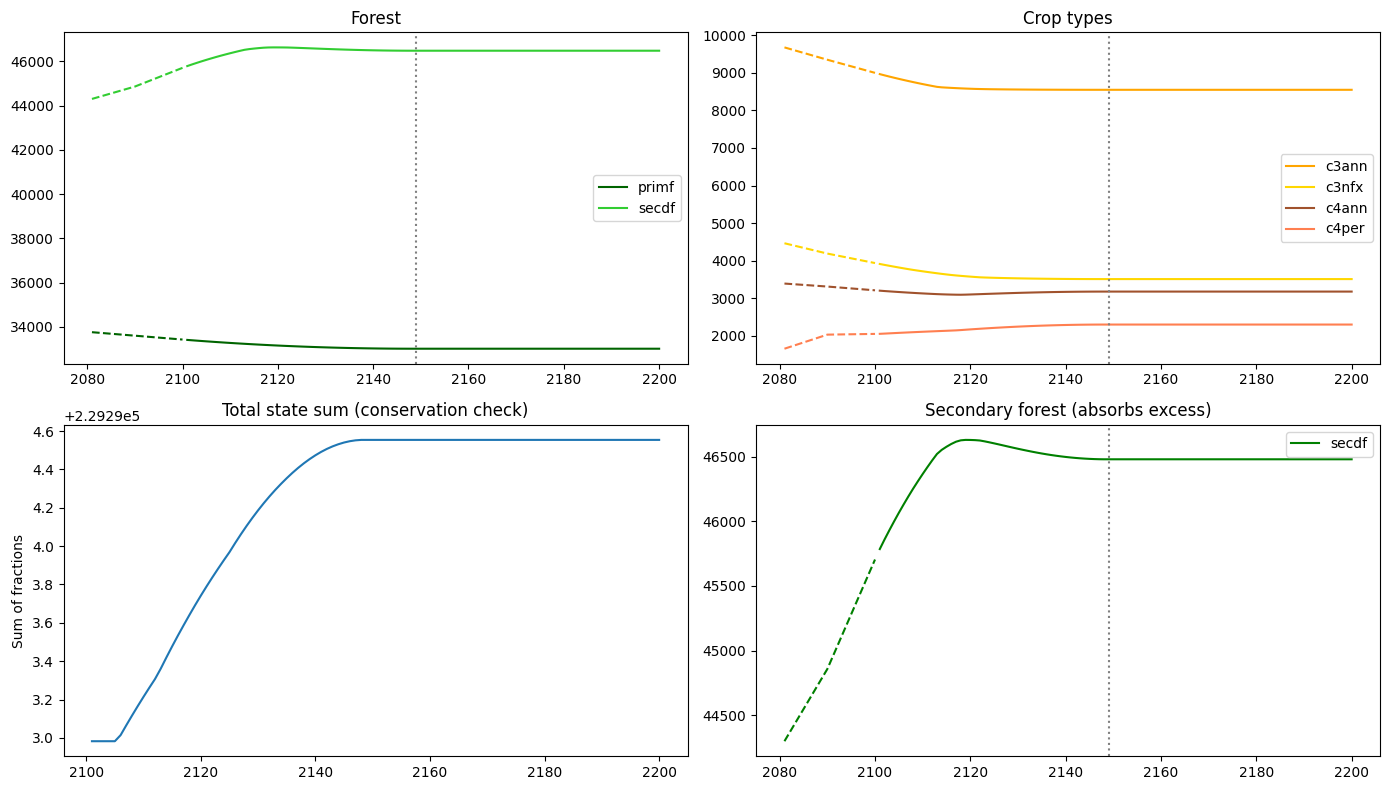

In [6]:
importlib.reload(src.extend)
from src.extend import extend_states

ext_years = np.arange(2101, 2201)  # Just first 100 years for quick check
ext = extend_states(vals, rates, ext_years)

# Plot global sums
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# Forest
ax = axes[0, 0]
for v, c in [('primf', 'darkgreen'), ('secdf', 'limegreen')]:
    # Historical (last 20 yr of input)
    hist = [np.nansum(ds_states[v].isel(time=t).values) for t in range(-20, 0)]
    hist_yrs = np.arange(2081, 2101)
    ext_sums = [np.nansum(ext[v][t]) for t in range(len(ext_years))]
    ax.plot(hist_yrs, hist, c=c, ls='--')
    ax.plot(ext_years, ext_sums, c=c, label=v)
ax.axvline(cfg.YR_AFOLU_ZERO, color='gray', ls=':')
ax.set_title('Forest'); ax.legend()

# Cropland
ax = axes[0, 1]
for v, c in [('c3ann', 'orange'), ('c3nfx', 'gold'), ('c4ann', 'sienna'), ('c4per', 'coral')]:
    hist = [np.nansum(ds_states[v].isel(time=t).values) for t in range(-20, 0)]
    hist_yrs = np.arange(2081, 2101)
    ext_sums = [np.nansum(ext[v][t]) for t in range(len(ext_years))]
    ax.plot(hist_yrs, hist, c=c, ls='--')
    ax.plot(ext_years, ext_sums, c=c, label=v)
ax.axvline(cfg.YR_AFOLU_ZERO, color='gray', ls=':')
ax.set_title('Crop types'); ax.legend()

# Total coverage check
ax = axes[1, 0]
total_ext = np.zeros(len(ext_years))
for v in cfg.STATE_VARS:
    total_ext += np.array([np.nansum(ext[v][t]) for t in range(len(ext_years))])
ax.plot(ext_years, total_ext)
ax.set_title('Total state sum (conservation check)')
ax.set_ylabel('Sum of fractions')

# secdf (absorbs excess)
ax = axes[1, 1]
hist_secdf = [np.nansum(ds_states['secdf'].isel(time=t).values) for t in range(-20, 0)]
ext_secdf = [np.nansum(ext['secdf'][t]) for t in range(len(ext_years))]
ax.plot(np.arange(2081, 2101), hist_secdf, 'g--')
ax.plot(ext_years, ext_secdf, 'g-', label='secdf')
ax.axvline(cfg.YR_AFOLU_ZERO, color='gray', ls=':')
ax.set_title('Secondary forest (absorbs excess)'); ax.legend()

plt.tight_layout(); plt.show()

## 5. BECCS biofuel scaling

Biofuel crop fractions (`crpbiof`) are scaled each year by the BECCS ratio from the CSV, capped at 1.0 per cell. This keeps scaling within existing cropland — no state fractions are modified, so the sum-to-one constraint is unaffected.

The plot compares the target factor (from the CSV) against the achieved global factor. Any divergence reflects cells hitting the cap, meaning the local biofuel fraction has saturated. In practice this affects a small share of total area.

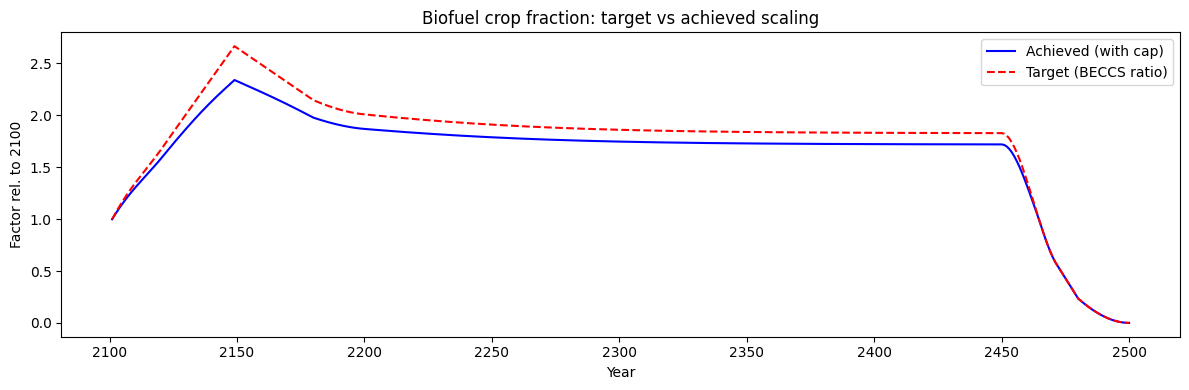

In [7]:
from src.extend import extend_biofuel

ds_biof = load_biof()
crpbiof_2100 = ds_biof['crpbiof'].isel(time=-1).values

ext_years_full = np.arange(2101, 2501)
beccs_dict = beccs.to_dict()
crpbiof_ext = extend_biofuel(crpbiof_2100, beccs_dict, ext_years_full)

# Global sum of crpbiof over time
sums = [np.nansum(crpbiof_ext[t]) for t in range(len(ext_years_full))]
sum_2100 = np.nansum(crpbiof_2100)
achieved_factors = np.array(sums) / sum_2100

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(ext_years_full, achieved_factors, 'b-', label='Achieved (with cap)')
target_factors = [beccs_dict.get(int(y), 1.0) for y in ext_years_full]
ax.plot(ext_years_full, target_factors, 'r--', label='Target (BECCS ratio)')
ax.set_xlabel('Year'); ax.set_ylabel('Factor rel. to 2100')
ax.set_title('Biofuel crop fraction: target vs achieved scaling')
ax.legend(); plt.tight_layout(); plt.show()

ds_biof.close()

In [8]:
ds_states.close()